# Parcial 3 - Clasificación del riesgo de agotamiento

**Carnet:** U20231085
**Random state:** 20231085

Se trabaja con el archivo `Parcial 3 - DT6.csv`, compuesto por 1800 registros y variables laborales relacionadas con jornada, pantalla, reuniones, descansos, sue?o, productividad y agotamiento. La variable objetivo es `burnout_risk`.

## Librerías

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

RANDOM_STATE = 20231085
sns.set_theme(style="whitegrid", palette="Set2")

## a) An?lisis de todas las variables

In [2]:
datos = pd.read_csv("Parcial 3 - DT6.csv")
datos.head()

,user_id,day_type,work_hours,screen_time_hours,meetings_count,breaks_taken,after_hours_work,sleep_hours,task_completion_rate,burnout_score,burnout_risk
0,1,Weekday,9.59,11.86,4,2,0,7.55,91.2,19.17,Low
1,1,Weekend,7.38,10.33,4,1,0,6.69,82.0,29.70,Low
2,1,Weekend,6.31,8.92,1,2,0,8.87,80.6,32.93,Low
3,1,Weekday,8.34,10.70,4,1,1,8.13,70.0,45.47,Low
4,1,Weekend,6.97,9.83,1,2,0,5.85,67.1,51.61,Low


In [3]:
print("Dimension:", datos.shape)
datos.info()

Dimension: (1800, 11)
<class 'pandas.DataFrame'>
RangeIndex: 1800 entries, 0 to 1799
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   user_id               1800 non-null   int64  
 1   day_type              1800 non-null   str    
 2   work_hours            1800 non-null   float64
 3   screen_time_hours     1800 non-null   float64
 4   meetings_count        1800 non-null   int64  
 5   breaks_taken          1800 non-null   int64  
 6   after_hours_work      1800 non-null   int64  
 7   sleep_hours           1800 non-null   float64
 8   task_completion_rate  1800 non-null   float64
 9   burnout_score         1800 non-null   float64
 10  burnout_risk          1800 non-null   str    
dtypes: float64(5), int64(4), str(2)
memory usage: 173.2 KB


In [4]:
datos.describe(include="all")

,user_id,day_type,work_hours,screen_time_hours,meetings_count,breaks_taken,after_hours_work,sleep_hours,task_completion_rate,burnout_score,burnout_risk
count,1800.000000,1800,1800.000000,1800.000000,1800.000000,1800.000000,1800.000000,1800.000000,1800.000000,1800.000000,1800
unique,NaN,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3
top,NaN,Weekend,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Low
freq,NaN,924,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1527
mean,90.500000,NaN,6.515117,9.271406,1.941111,3.028889,0.358889,6.996467,72.308556,44.009978,NaN
std,51.975162,NaN,2.290521,2.409253,1.696178,1.417844,0.479808,1.061740,14.978647,23.881782,NaN
min,1.000000,NaN,3.000000,4.510000,0.000000,1.000000,0.000000,4.500000,40.000000,2.500000,NaN
25%,45.750000,NaN,4.430000,7.240000,1.000000,2.000000,0.000000,6.280000,62.300000,25.370000,NaN
50%,90.500000,NaN,6.445000,9.210000,2.000000,3.000000,0.000000,6.990000,74.500000,39.270000,NaN
75%,135.250000,NaN,8.510000,11.310000,3.000000,4.000000,1.000000,7.750000,83.700000,58.197500,NaN


In [5]:
nulos = datos.isnull().sum().to_frame("nulos")
nulos["porcentaje"] = (nulos["nulos"] / len(datos) * 100).round(2)
nulos

,nulos,porcentaje
user_id,0,0.0
day_type,0,0.0
work_hours,0,0.0
screen_time_hours,0,0.0
meetings_count,0,0.0
breaks_taken,0,0.0
after_hours_work,0,0.0
sleep_hours,0,0.0
task_completion_rate,0,0.0
burnout_score,0,0.0


In [6]:
for columna in ["day_type", "after_hours_work", "burnout_risk"]:
    print()
    print(f"Frecuencias de {columna}")
    print(datos[columna].value_counts())


Frecuencias de day_type
day_type
Weekend    924
Weekday    876
Name: count, dtype: int64

Frecuencias de after_hours_work
after_hours_work
0    1154
1     646
Name: count, dtype: int64

Frecuencias de burnout_risk
burnout_risk
Low       1527
Medium     253
High        20
Name: count, dtype: int64


El conjunto contiene 1800 observaciones y 11 variables. No hay valores nulos. La variable objetivo `burnout_risk` tiene tres categorías y está desbalanceada, ya que la categoría `Low` es la más frecuente.

### Análisis gráfico de la variable respuesta

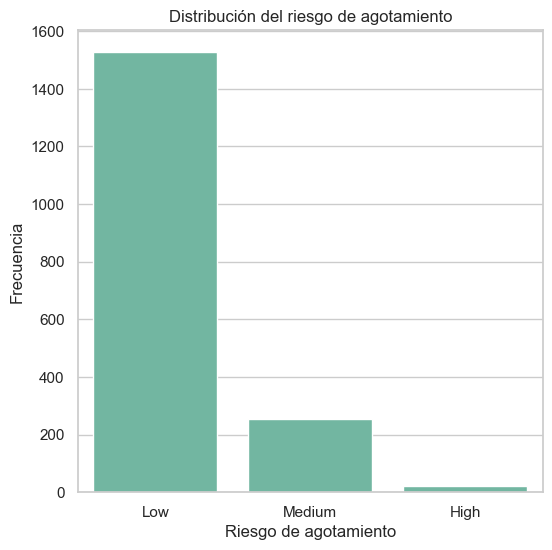

burnout_risk
Low       84.83
Medium    14.06
High       1.11
Name: proportion, dtype: float64

In [23]:
plt.figure(figsize=(6,6))
sns.countplot(data=datos, x="burnout_risk", order=["Low", "Medium", "High"])
plt.title("Distribución del riesgo de agotamiento")
plt.xlabel("Riesgo de agotamiento")
plt.ylabel("Frecuencia")
plt.show()

(datos["burnout_risk"].value_counts(normalize=True) * 100).round(2)

### Análisis gráfico de variables predictoras numéricas

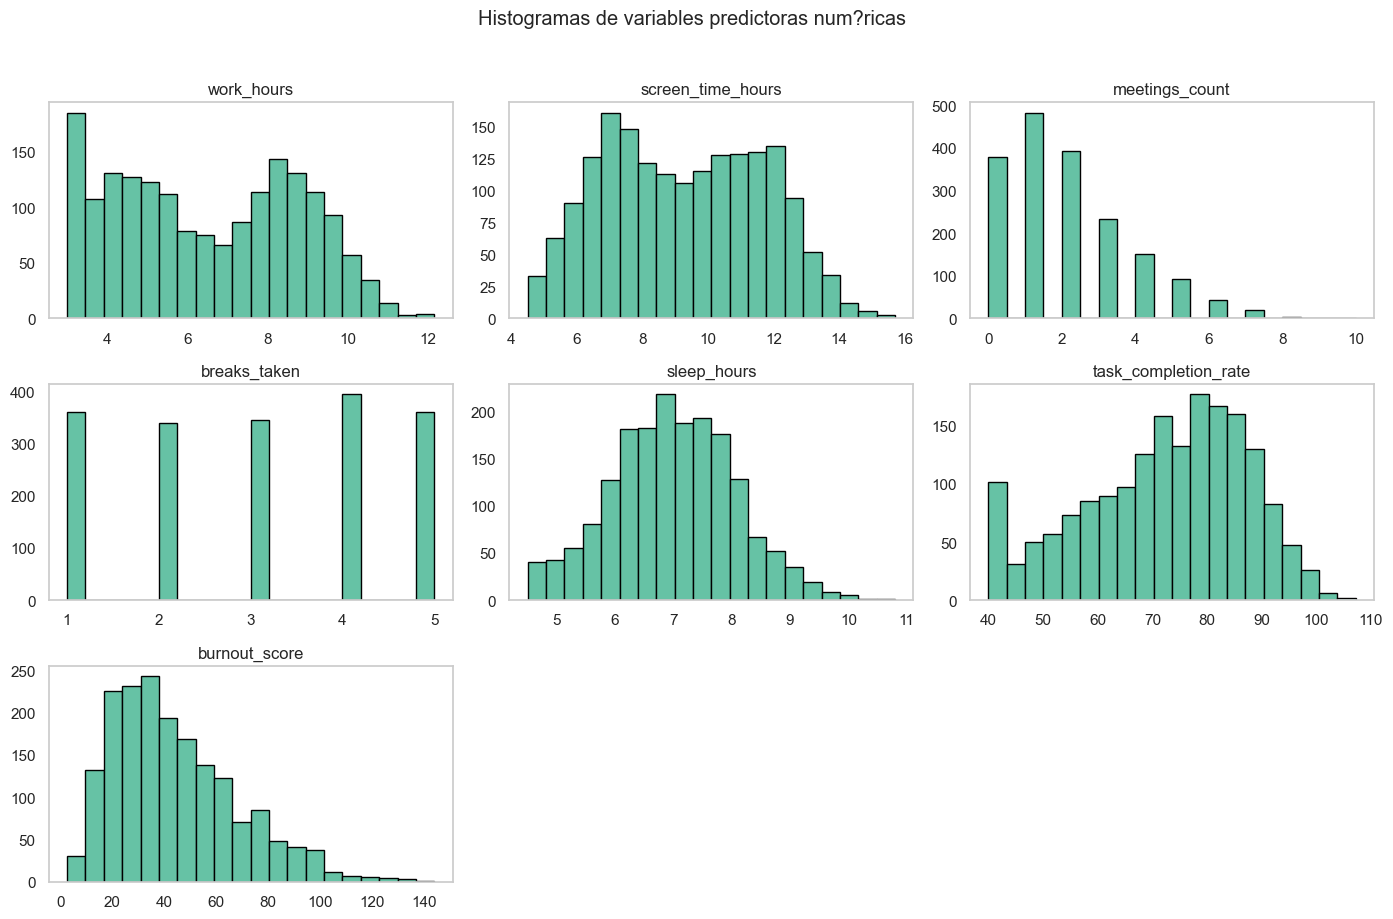

In [18]:
variables_numericas = [
    "work_hours", "screen_time_hours", "meetings_count", "breaks_taken",
    "sleep_hours", "task_completion_rate", "burnout_score"
]

datos[variables_numericas].hist(figsize=(14, 9), bins=20, edgecolor="black", grid=False)
plt.suptitle("Histogramas de variables predictoras numéricas", y=1.02)
plt.tight_layout()
plt.show()

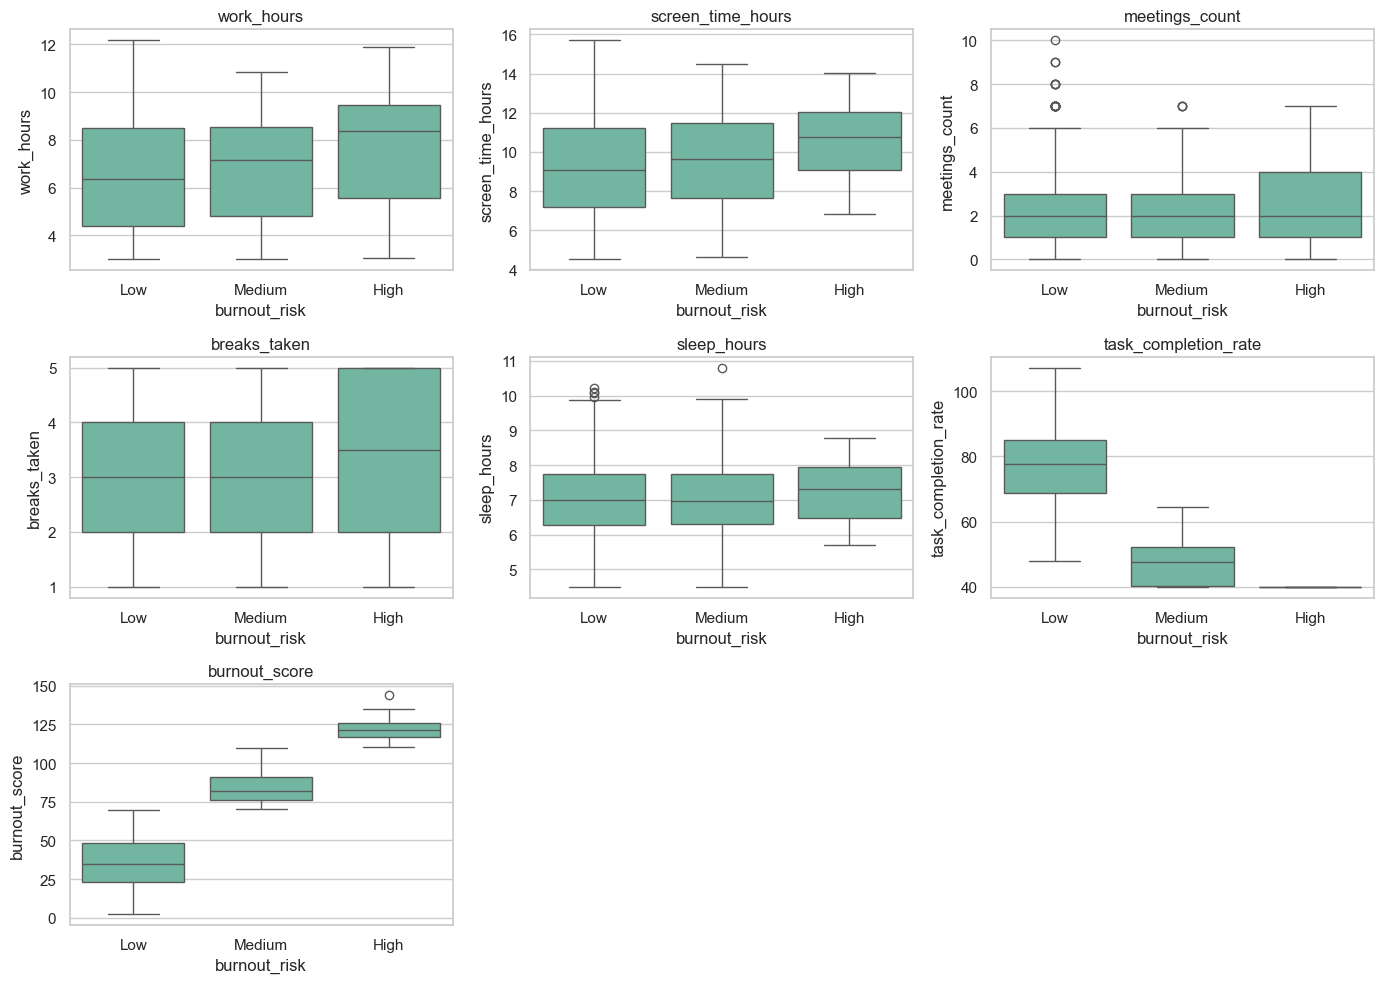

In [19]:
fig, axes = plt.subplots(3, 3, figsize=(14, 10))
axes = axes.ravel()
for i, variable in enumerate(variables_numericas):
    sns.boxplot(data=datos, x="burnout_risk", y=variable, ax=axes[i], order=["Low", "Medium", "High"])
    axes[i].set_title(variable)
    axes[i].set_xlabel("burnout_risk")
for j in range(len(variables_numericas), len(axes)):
    axes[j].axis("off")
plt.tight_layout()
plt.show()

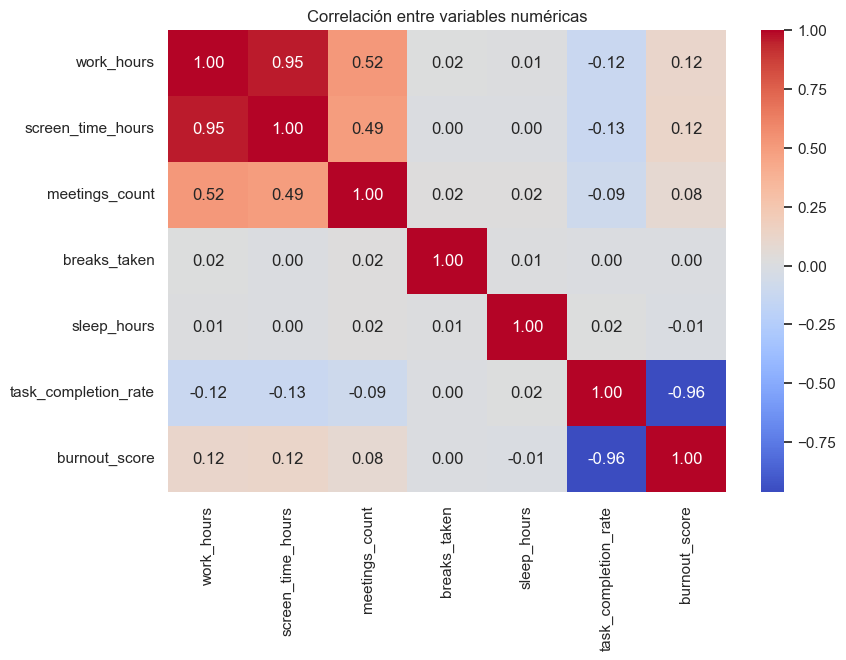

In [24]:
plt.figure(figsize=(9, 6))
sns.heatmap(datos[variables_numericas].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlación entre variables numéricas")
plt.show()

### Análisis gráfico de variables categóricas y binarias

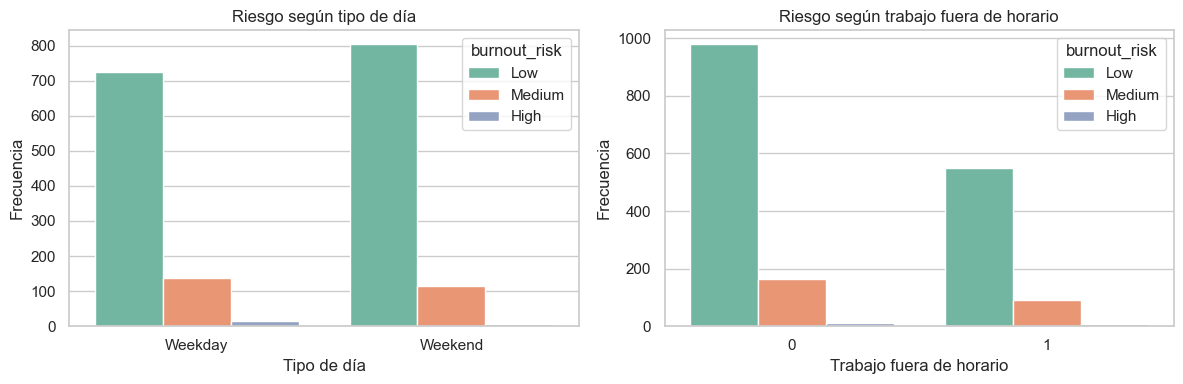

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.countplot(data=datos, x="day_type", hue="burnout_risk", hue_order=["Low", "Medium", "High"], ax=axes[0])
axes[0].set_title("Riesgo según tipo de día")
axes[0].set_xlabel("Tipo de día")
axes[0].set_ylabel("Frecuencia")

sns.countplot(data=datos, x="after_hours_work", hue="burnout_risk", hue_order=["Low", "Medium", "High"], ax=axes[1])
axes[1].set_title("Riesgo según trabajo fuera de horario")
axes[1].set_xlabel("Trabajo fuera de horario")
axes[1].set_ylabel("Frecuencia")
plt.tight_layout()
plt.show()

Para el modelado se excluye `user_id`, porque es un identificador y no una característica laboral. Las variables predictoras utilizadas son todas las demás variables excepto `burnout_risk`.

In [28]:
respuesta = "burnout_risk"
variables_modelo = [col for col in datos.columns if col not in ["user_id", respuesta]]
X = datos[variables_modelo].copy()
y = datos[respuesta].copy()

variables_categoricas = ["day_type"]
variables_numericas_modelo = [col for col in X.columns if col not in variables_categoricas]

print("Variables predictoras utilizadas:")
print(variables_modelo)

Variables predictoras utilizadas:
['day_type', 'work_hours', 'screen_time_hours', 'meetings_count', 'breaks_taken', 'after_hours_work', 'sleep_hours', 'task_completion_rate', 'burnout_score']


## b) División de entrenamiento y validación

In [30]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)

print("Entrenamiento:", X_train.shape)
print("Validacion:", X_test.shape)
print("Distribucion de la respuesta en validacion:")
print(y_test.value_counts())

Entrenamiento: (1440, 9)
Validacion: (360, 9)
Distribucion de la respuesta en validacion:
burnout_risk
Low       305
Medium     51
High        4
Name: count, dtype: int64


In [33]:
resultados = []
modelos_entrenados = {}
orden_clases = ["Low", "Medium", "High"]

def evaluar_modelo(nombre, modelo, X_validacion, y_validacion):
    pred = modelo.predict(X_validacion)
    accuracy = accuracy_score(y_validacion, pred)
    resultados.append({"modelo": nombre, "accuracy": accuracy})
    print(f"Accuracy de {nombre}: {accuracy:.4f}")
    print()
    print("Reporte de clasificacion")
    print(classification_report(y_validacion, pred, zero_division=0))
    cm = confusion_matrix(y_validacion, pred, labels=orden_clases)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=orden_clases, yticklabels=orden_clases)
    plt.xlabel("Predicho")
    plt.ylabel("Real")
    plt.title(f"Matriz de confusión - {nombre}")
    plt.show()
    return accuracy, pred

## c) KNN usando dos variables predictoras

Se usan `burnout_score` y `sleep_hours`, porque el puntaje de agotamiento resume directamente el fen?meno y las horas de sue?o representan recuperaci?n diaria.

Mejor k: 2
Mejor accuracy: 0.9917


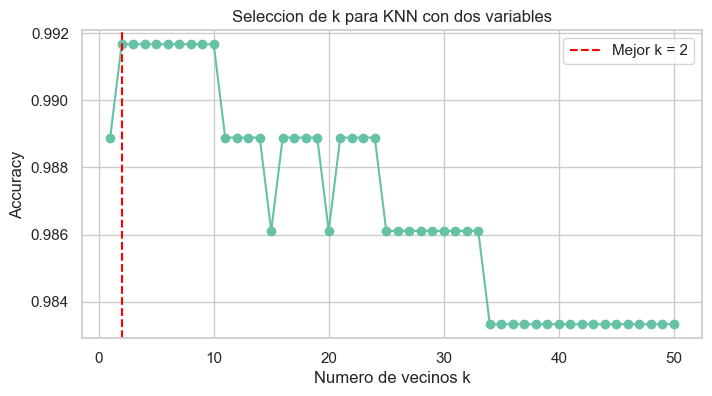

In [35]:
variables_knn_2 = ["burnout_score", "sleep_hours"]
X2 = datos[variables_knn_2]
y2 = datos[respuesta]

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.20, random_state=RANDOM_STATE, stratify=y2
)

accuracy_k = []
for k in range(1, 51):
    modelo = Pipeline(steps=[
        ("escalador", StandardScaler()),
        ("knn", KNeighborsClassifier(n_neighbors=k))
    ])
    modelo.fit(X2_train, y2_train)
    pred = modelo.predict(X2_test)
    accuracy_k.append(accuracy_score(y2_test, pred))

mejor_k_2 = int(np.argmax(accuracy_k) + 1)
print("Mejor k:", mejor_k_2)
print("Mejor accuracy:", round(max(accuracy_k), 4))

plt.figure(figsize=(8, 4))
plt.plot(range(1, 51), accuracy_k, marker="o")
plt.axvline(mejor_k_2, color="red", linestyle="--", label=f"Mejor k = {mejor_k_2}")
plt.xlabel("Numero de vecinos k")
plt.ylabel("Accuracy")
plt.title("Seleccion de k para KNN con dos variables")
plt.legend()
plt.show()

Accuracy de KNN dos variables: 0.9917

Reporte de clasificacion
              precision    recall  f1-score   support

        High       1.00      0.75      0.86         4
         Low       0.99      1.00      1.00       305
      Medium       0.98      0.96      0.97        51

    accuracy                           0.99       360
   macro avg       0.99      0.90      0.94       360
weighted avg       0.99      0.99      0.99       360



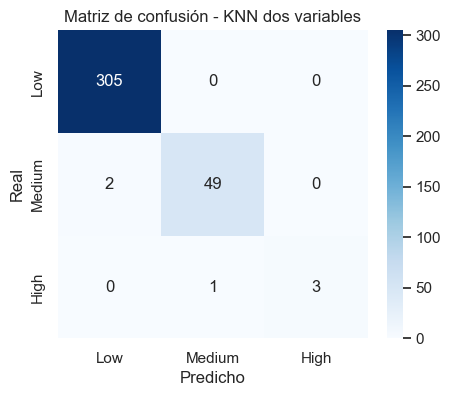

In [36]:
knn_2 = Pipeline(steps=[
    ("escalador", StandardScaler()),
    ("knn", KNeighborsClassifier(n_neighbors=mejor_k_2))
])
knn_2.fit(X2_train, y2_train)
modelos_entrenados["KNN dos variables"] = knn_2
accuracy_knn_2, pred_knn_2 = evaluar_modelo("KNN dos variables", knn_2, X2_test, y2_test)

## d) KNN usando todas las variables independientes

Mejor k: 15
Mejor accuracy: 0.9639


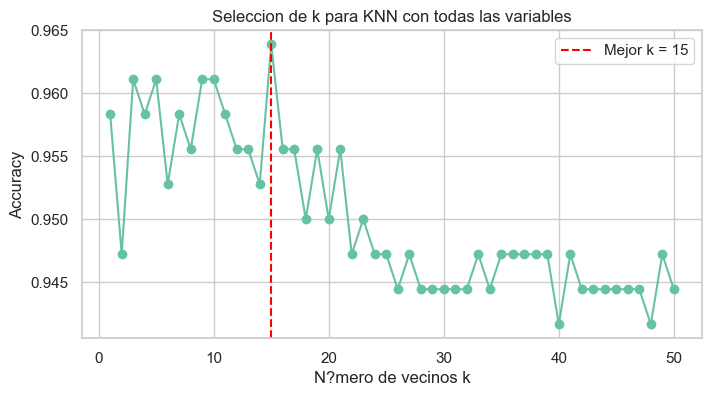

In [38]:
preprocesamiento_knn = ColumnTransformer(transformers=[
    ("numericas", StandardScaler(), variables_numericas_modelo),
    ("categoricas", OneHotEncoder(drop="first", handle_unknown="ignore"), variables_categoricas)
])

accuracy_k_todas = []
for k in range(1, 51):
    modelo = Pipeline(steps=[
        ("preprocesamiento", preprocesamiento_knn),
        ("knn", KNeighborsClassifier(n_neighbors=k))
    ])
    modelo.fit(X_train, y_train)
    pred = modelo.predict(X_test)
    accuracy_k_todas.append(accuracy_score(y_test, pred))

mejor_k_todas = int(np.argmax(accuracy_k_todas) + 1)
print("Mejor k:", mejor_k_todas)
print("Mejor accuracy:", round(max(accuracy_k_todas), 4))

plt.figure(figsize=(8, 4))
plt.plot(range(1, 51), accuracy_k_todas, marker="o")
plt.axvline(mejor_k_todas, color="red", linestyle="--", label=f"Mejor k = {mejor_k_todas}")
plt.xlabel("N?mero de vecinos k")
plt.ylabel("Accuracy")
plt.title("Seleccion de k para KNN con todas las variables")
plt.legend()
plt.show()

Accuracy de KNN todas las variables: 0.9639

Reporte de clasificacion
              precision    recall  f1-score   support

        High       0.00      0.00      0.00         4
         Low       0.97      1.00      0.99       305
      Medium       0.90      0.84      0.87        51

    accuracy                           0.96       360
   macro avg       0.62      0.61      0.62       360
weighted avg       0.95      0.96      0.96       360



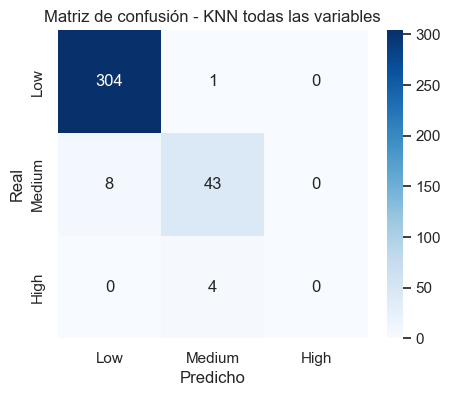

In [39]:
knn_todas = Pipeline(steps=[
    ("preprocesamiento", preprocesamiento_knn),
    ("knn", KNeighborsClassifier(n_neighbors=mejor_k_todas))
])
knn_todas.fit(X_train, y_train)
modelos_entrenados["KNN todas las variables"] = knn_todas
accuracy_knn_todas, pred_knn_todas = evaluar_modelo("KNN todas las variables", knn_todas, X_test, y_test)

## e) Árbol de decision

Se indica que el mínimo número de observaciones que debe contener cada nodo hoja es 100 mediante `min_samples_leaf=100`.

Accuracy de Arbol de decision: 0.9889

Reporte de clasificacion
              precision    recall  f1-score   support

        High       0.00      0.00      0.00         4
         Low       1.00      1.00      1.00       305
      Medium       0.93      1.00      0.96        51

    accuracy                           0.99       360
   macro avg       0.64      0.67      0.65       360
weighted avg       0.98      0.99      0.98       360



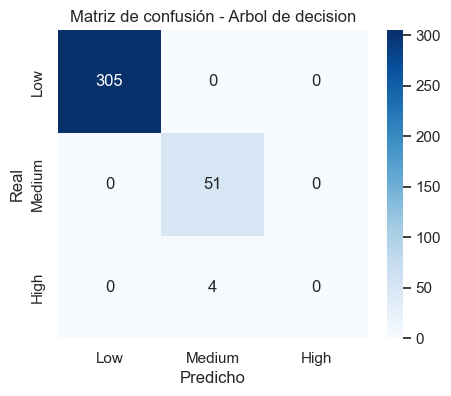

In [41]:
preprocesamiento_arbol = ColumnTransformer(transformers=[
    ("numericas", "passthrough", variables_numericas_modelo),
    ("categoricas", OneHotEncoder(drop="first", handle_unknown="ignore"), variables_categoricas)
])

arbol = Pipeline(steps=[
    ("preprocesamiento", preprocesamiento_arbol),
    ("arbol", DecisionTreeClassifier(min_samples_leaf=100, random_state=RANDOM_STATE))
])
arbol.fit(X_train, y_train)
modelos_entrenados["Arbol de decision"] = arbol
accuracy_arbol, pred_arbol = evaluar_modelo("Arbol de decision", arbol, X_test, y_test)

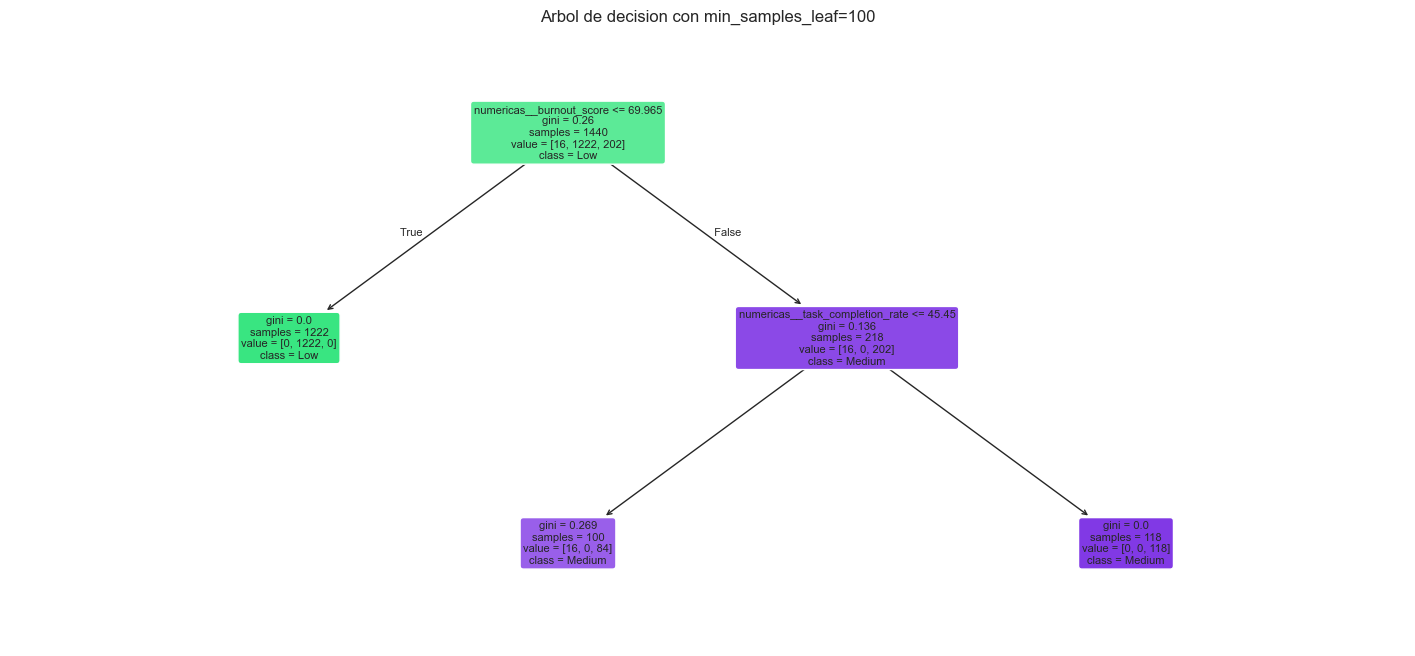

In [43]:
nombres_arbol = arbol.named_steps["preprocesamiento"].get_feature_names_out()
plt.figure(figsize=(18, 8))
plot_tree(
    arbol.named_steps["arbol"],
    feature_names=nombres_arbol,
    class_names=arbol.named_steps["arbol"].classes_,
    filled=True,
    rounded=True,
    fontsize=8
)
plt.title("Arbol de decision con min_samples_leaf=100")
plt.show()

## f) Modelos de ensamble

### Con reemplazamiento

Accuracy de Bagging con reemplazamiento: 1.0000

Reporte de clasificacion
              precision    recall  f1-score   support

        High       1.00      1.00      1.00         4
         Low       1.00      1.00      1.00       305
      Medium       1.00      1.00      1.00        51

    accuracy                           1.00       360
   macro avg       1.00      1.00      1.00       360
weighted avg       1.00      1.00      1.00       360



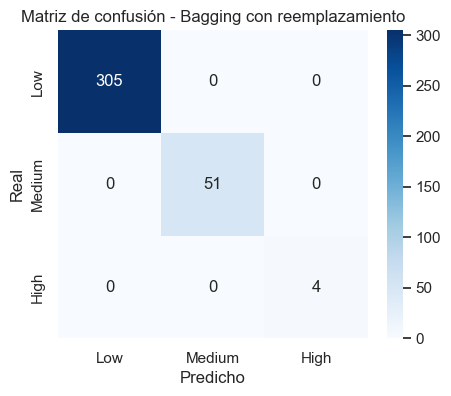

In [44]:
bagging_reemplazo = Pipeline(steps=[
    ("preprocesamiento", preprocesamiento_arbol),
    ("modelo", BaggingClassifier(
        estimator=DecisionTreeClassifier(random_state=RANDOM_STATE),
        n_estimators=100,
        bootstrap=True,
        random_state=RANDOM_STATE
    ))
])
bagging_reemplazo.fit(X_train, y_train)
modelos_entrenados["Bagging con reemplazamiento"] = bagging_reemplazo
accuracy_bagging_reemplazo, pred_bagging_reemplazo = evaluar_modelo("Bagging con reemplazamiento", bagging_reemplazo, X_test, y_test)

### Sin reemplazamiento

Accuracy de Bagging sin reemplazamiento: 1.0000

Reporte de clasificacion
              precision    recall  f1-score   support

        High       1.00      1.00      1.00         4
         Low       1.00      1.00      1.00       305
      Medium       1.00      1.00      1.00        51

    accuracy                           1.00       360
   macro avg       1.00      1.00      1.00       360
weighted avg       1.00      1.00      1.00       360



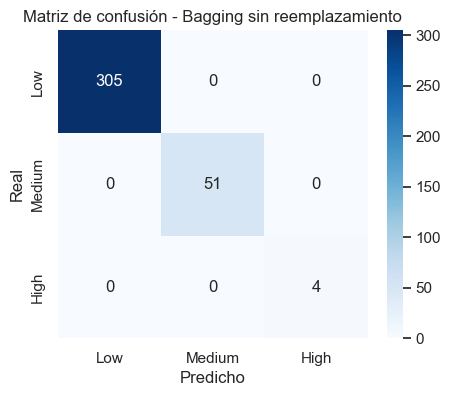

In [45]:
bagging_sin_reemplazo = Pipeline(steps=[
    ("preprocesamiento", preprocesamiento_arbol),
    ("modelo", BaggingClassifier(
        estimator=DecisionTreeClassifier(random_state=RANDOM_STATE),
        n_estimators=100,
        bootstrap=False,
        random_state=RANDOM_STATE
    ))
])
bagging_sin_reemplazo.fit(X_train, y_train)
modelos_entrenados["Bagging sin reemplazamiento"] = bagging_sin_reemplazo
accuracy_bagging_sin_reemplazo, pred_bagging_sin_reemplazo = evaluar_modelo("Bagging sin reemplazamiento", bagging_sin_reemplazo, X_test, y_test)

### Random Forest

Se fija `max_leaf_nodes=8`, el máximo de nodos hoja por árbol es 8.

Accuracy de Random Forest: 0.9972

Reporte de clasificacion
              precision    recall  f1-score   support

        High       1.00      0.75      0.86         4
         Low       1.00      1.00      1.00       305
      Medium       0.98      1.00      0.99        51

    accuracy                           1.00       360
   macro avg       0.99      0.92      0.95       360
weighted avg       1.00      1.00      1.00       360



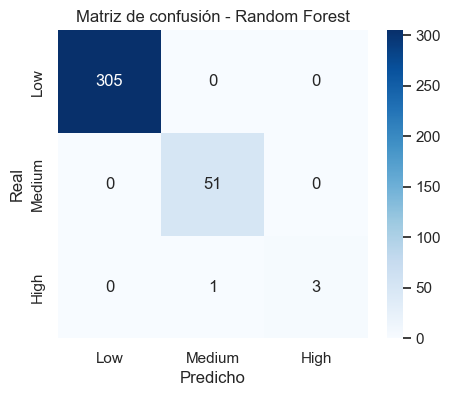

In [46]:
random_forest = Pipeline(steps=[
    ("preprocesamiento", preprocesamiento_arbol),
    ("modelo", RandomForestClassifier(
        n_estimators=200,
        max_leaf_nodes=8,
        random_state=RANDOM_STATE
    ))
])
random_forest.fit(X_train, y_train)
modelos_entrenados["Random Forest"] = random_forest
accuracy_rf, pred_rf = evaluar_modelo("Random Forest", random_forest, X_test, y_test)

### Gradient Boosting ajustado

Se ajusta el modelo con b?squeda en malla sobre cantidad de ?rboles, tasa de aprendizaje, profundidad m?xima y m?nimo de observaciones por hoja.

Mejores parametros:
{'modelo__learning_rate': 0.05, 'modelo__max_depth': 2, 'modelo__min_samples_leaf': 20, 'modelo__n_estimators': 100}
Mejor accuracy promedio en validacion cruzada: 0.991
Accuracy de Gradient Boosting ajustado: 0.9972

Reporte de clasificacion
              precision    recall  f1-score   support

        High       0.80      1.00      0.89         4
         Low       1.00      1.00      1.00       305
      Medium       1.00      0.98      0.99        51

    accuracy                           1.00       360
   macro avg       0.93      0.99      0.96       360
weighted avg       1.00      1.00      1.00       360



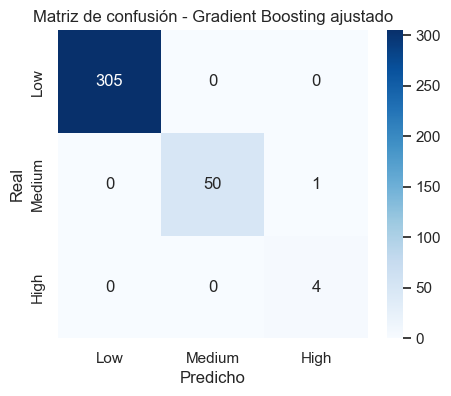

In [48]:
gb_pipeline = Pipeline(steps=[
    ("preprocesamiento", preprocesamiento_arbol),
    ("modelo", GradientBoostingClassifier(random_state=RANDOM_STATE))
])

param_grid_gb = {
    "modelo__n_estimators": [100, 200],
    "modelo__learning_rate": [0.05, 0.10],
    "modelo__max_depth": [2, 3],
    "modelo__min_samples_leaf": [20, 50]
}

grid_gb = GridSearchCV(
    gb_pipeline,
    param_grid=param_grid_gb,
    scoring="accuracy",
    cv=5,
    n_jobs=1
)
grid_gb.fit(X_train, y_train)

print("Mejores parametros:")
print(grid_gb.best_params_)
print("Mejor accuracy promedio en validacion cruzada:", round(grid_gb.best_score_, 4))

gradient_boosting = grid_gb.best_estimator_
modelos_entrenados["Gradient Boosting ajustado"] = gradient_boosting
accuracy_gb, pred_gb = evaluar_modelo("Gradient Boosting ajustado", gradient_boosting, X_test, y_test)

### Comparación de modelos

In [ ]:
tabla_resultados = pd.DataFrame(resultados).sort_values("accuracy", ascending=False).reset_index(drop=True)
tabla_resultados

In [ ]:
plt.figure(figsize=(9, 5))
sns.barplot(data=tabla_resultados, y="modelo", x="accuracy", palette="viridis")
plt.xlim(0, 1.05)
plt.title("Comparación de accuracy por modelo")
plt.xlabel("Accuracy")
plt.ylabel("Modelo")
plt.show()

## g) Clasificación usando la moda de las variables predictoras

Se calcula la moda de cada variable predictora y se clasifica esa observación usando el modelo con mejor `accuracy` en validación.

In [ ]:
mejor_modelo_nombre = tabla_resultados.loc[0, "modelo"]
mejor_modelo = modelos_entrenados[mejor_modelo_nombre]

observacion_moda = X.mode().iloc[[0]]
observacion_moda

In [ ]:
prediccion_moda = mejor_modelo.predict(observacion_moda)[0]

print("Modelo con mejor rendimiento:", mejor_modelo_nombre)
print("Accuracy del mejor modelo:", round(tabla_resultados.loc[0, "accuracy"], 4))
print("Clasificacion para la persona con la moda de las variables predictoras:", prediccion_moda)

### Resumen de resultados

Al ejecutar las celdas del notebook se obtuvieron estos resultados principales:

| Modelo                      | Accuracy |
|-----------------------------|---:|
| Bagging con reemplazamiento | 1.0000 |
| Bagging sin reemplazamiento | 1.0000 |
| Random Forest               | 0.9972 |
| Gradient Boosting ajustado  | 0.9972 |
| KNN dos variables           | 0.9917 |
| Árbol de decisión           | 0.9889 |
| KNN todas las variables     | 0.9639 |

El modelo seleccionado por la tabla ordenada es **Bagging con reemplazamiento** y la clasificación para la persona formada con la moda de las variables predictoras es **Low**.

## Conclusiones

- falta